# SARIMA Forecasting Notebook — MCC 4121

This notebook builds a merchant-level weekly SARIMA forecasting pipeline for **MCC 4121** merchants.

Data is sourced directly from the `thiru1711/Financial_Transactions` HuggingFace dataset,
with processing costs applied via the `cost_type_id.csv` costing engine.

**Targets:** TPV · TPC · ATS · TPC Margin (% of TPV)

**Structure:**
1. Environment & Data Ingestion (HuggingFace → mcc=4121 → costing)
2. Merchant-level Train / Validate Split
3. Weekly Aggregation
4. Pivot Tables
5. EDA
6. Global SARIMA Order Selection
7. Merchant Feature Vectors
8. SARIMA Model Training
9. Validation Evaluation (input: last 4 wks 2017 → forecast: 12 wks 2018)
10. k-NN Warm-Start Function
11. Validation Performance Metrics & Visualisation
12. TPC Margin Percentile Forecast (P5 / P95)
13. Model Persistence

In [1]:
# ── Section 1 — Environment Setup & Data Ingestion ─────────────────────────
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pickle, random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Constants ───────────────────────────────────────────────────────────────
TARGET_MCC         = 4121
DEFAULT_K          = 5
OUTLIER_THRESHOLD  = 5.0
MIN_TRAIN_WEEKS    = 52        # at least 1 full year of weekly data to train
SEASONAL_PERIOD    = 52
INPUT_N_WEEKS      = 4         # last 4 weeks of 2017 used as SARIMA input
TARGET_N_WEEKS     = 12        # first 12 weeks of 2018 used as forecast target
INPUT_YEAR         = 2017
TARGET_YEAR        = 2018

MAX_MERCHANTS_TRAIN = None     # set to int to cap during experimentation
MAX_MERCHANTS_EVAL  = None

np.random.seed(42)
random.seed(42)

In [2]:
# ── Step 1a: Install / load datasets ────────────────────────────────────────
try:
    from datasets import load_dataset
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'datasets'])
    from datasets import load_dataset

# ── Step 1b: Load HuggingFace dataset ───────────────────────────────────────
print('Loading thiru1711/Financial_Transactions from HuggingFace …')
ds = load_dataset("thiru1711/Financial_Transactions")
df_raw = ds['train'].to_pandas()
print(f'  Raw shape: {df_raw.shape}')

Loading thiru1711/Financial_Transactions from HuggingFace …


  Raw shape: (13305915, 37)


In [4]:
# ── Step 1c: Drop unneeded columns (follow 03_Apply_Txn_Proc_Cost) ──────────
drop_cols = [
    'card_number', 'cvv', 'expires', 'address',
    'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender',
    'latitude', 'longitude', 'per_capita_income', 'yearly_income',
    'total_debt', 'credit_score', 'num_credit_cards', 'credit_limit',
    'card_id', 'acct_open_date', 'year_pin_last_changed',
    'card_on_dark_web', 'num_cards_issued',
    'merchant_state', 'zip', 'merchant_city', 'has_chip',
]
drop_cols = [c for c in drop_cols if c in df_raw.columns]
df = df_raw.drop(columns=drop_cols)

# Remove fraud
df = df[df['is_fraud'] != 1].copy()
df = df.drop(columns='is_fraud', errors='ignore')

# Clean mcc
df['mcc'] = pd.to_numeric(df['mcc'], errors='coerce')
df = df.dropna(subset=['mcc'])
df['mcc'] = df['mcc'].astype(float)

# Rename Debit (Prepaid) → Prepaid
df['card_type'] = df['card_type'].replace('Debit (Prepaid)', 'Prepaid')

# ── Step 1d: Filter to MCC 4121 only ────────────────────────────────────────
df = df[df['mcc'] == TARGET_MCC].copy()
print(f'  After mcc={TARGET_MCC} filter: {df.shape}')
print(f'  Unique merchants: {df["merchant_id"].nunique()}')

# ── Step 1e: Parse date and clean amount ────────────────────────────────────
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df[df['date'].notna()].copy()
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df = df[df['amount'] > 0].copy()

# ── Step 1f: Apply proc_cost via cost_type_id.csv ───────────────────────────
# Download cost_type_id.csv from Google Drive if not present
COST_TYPE_PATH = Path('cost_type_id.csv')
if not COST_TYPE_PATH.exists():
    try:
        import gdown
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])
        import gdown
    url = 'https://drive.google.com/uc?id=1FA5cKHWMoalV3NOZqy0-_sxlx7EGwQPB'
    print('  Downloading cost_type_id.csv …')
    gdown.download(url, str(COST_TYPE_PATH), quiet=False)

cost_type_df = pd.read_csv(COST_TYPE_PATH)
cost_type_df['mcc'] = pd.to_numeric(cost_type_df['mcc'], errors='coerce')

# Costing engine (from 03_Apply_Txn_Proc_Cost)
df_filtered = df[df['card_brand'].isin(['Visa', 'Mastercard'])].copy()

cost_general  = cost_type_df[cost_type_df['mcc'].isna()].copy()
cost_specific = cost_type_df[cost_type_df['mcc'].notna()].copy()

# Small transactions (≤$5): general rules
df_small = df_filtered[df_filtered['amount'] <= 5].merge(
    cost_general, left_on=['card_brand', 'card_type'],
    right_on=['card_brand', 'card_type'], how='left', suffixes=('', '_cost')
)
df_small = df_small[
    (df_small['amount'] >= df_small['min_transaction_amt']) &
    (df_small['amount'] <= df_small['max_transaction_amt']) &
    (df_small['cost_type_ID'].notna())
].sort_values('transaction_id').drop_duplicates('transaction_id', keep='first')

# Large transactions (>$5): mcc-specific rules
df_large = df_filtered[df_filtered['amount'] > 5].merge(
    cost_specific, left_on=['card_brand', 'card_type', 'mcc'],
    right_on=['card_brand', 'card_type', 'mcc'], how='left', suffixes=('', '_cost')
)
df_large = df_large[
    (df_large['amount'] >= df_large['min_transaction_amt']) &
    (df_large['amount'] <= df_large['max_transaction_amt']) &
    (df_large['cost_type_ID'].notna())
].sort_values('transaction_id').drop_duplicates('transaction_id', keep='first')

cost_id_map = pd.concat([
    df_small[['transaction_id', 'cost_type_ID']],
    df_large[['transaction_id', 'cost_type_ID']]
]).set_index('transaction_id')['cost_type_ID']

df['cost_type_ID'] = df['transaction_id'].map(cost_id_map)

cost_type_df['subtotal_fee_percent_clean'] = (
    cost_type_df['subtotal_fee_percent'].str.rstrip('%').astype(float) / 100
)
cost_type_df['subtotal_fee_dollars_clean'] = (
    cost_type_df['subtotal_fee_dollars'].str.lstrip('$').astype(float)
)
fee_dollars_map = dict(zip(cost_type_df['cost_type_ID'], cost_type_df['subtotal_fee_dollars_clean']))
fee_percent_map = dict(zip(cost_type_df['cost_type_ID'], cost_type_df['subtotal_fee_percent_clean']))

df['proc_cost'] = (df['cost_type_ID'].map(fee_dollars_map)
                   + df['cost_type_ID'].map(fee_percent_map) * df['amount'])
df['proc_cost'] = df['proc_cost'].fillna(0.0)

# ── Step 1g: Add ISO year-week labels ───────────────────────────────────────
iso = df['date'].dt.isocalendar()
df['iso_year'] = iso['year'].astype(int)
df['iso_week'] = iso['week'].astype(int)
df['year_week'] = df['iso_year'].astype(str) + '-' + df['iso_week'].astype(str).str.zfill(2)

print(f'\nFinal dataset: {df.shape}')
print(f'Date range   : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Merchants    : {df["merchant_id"].nunique()}')
print(f'proc_cost coverage: {df["proc_cost"].gt(0).sum():,} / {len(df):,} rows')
display(df[['merchant_id', 'date', 'year_week', 'amount', 'proc_cost', 'mcc', 'card_brand', 'card_type']].head())


  After mcc=4121 filter: (500362, 10)
  Unique merchants: 3137

Final dataset: (500351, 15)
Date range   : 2010-01-01 → 2019-10-31
Merchants    : 3137
proc_cost coverage: 469,508 / 500,351 rows

Final dataset: (500351, 15)
Date range   : 2010-01-01 → 2019-10-31
Merchants    : 3137
proc_cost coverage: 469,508 / 500,351 rows


,merchant_id,date,year_week,amount,proc_cost,mcc,card_brand,card_type
13,33326,2010-01-01 00:27:00,2009-53,43.330002,0.307994,4121.0,Visa,Debit
26,16798,2010-01-01 00:45:00,2009-53,16.860001,0.446968,4121.0,Mastercard,Credit
41,16798,2010-01-01 01:11:00,2009-53,14.660000,0.405608,4121.0,Mastercard,Credit
46,29232,2010-01-01 01:19:00,2009-53,17.139999,0.476522,4121.0,Mastercard,Debit
57,16798,2010-01-01 01:46:00,2009-53,34.340000,0.774082,4121.0,Mastercard,Debit


## Section 2 — Merchant-Level Train / Validate Split

Merchants (not transactions) are split 80/20 into train and validate sets.

- **Train transactions**: all weeks in year ≤ 2017  
- **Validate transactions**: weeks 2017-49 → 2017-52 (input window) **and** 2018-01 → 2018-12 (target window)

This guarantees every validate merchant has both a 4-week look-back in 2017 and 12 known weeks in 2018.

In [5]:
# ── Section 2 — Merchant-Level Train / Validate Split ──────────────────────

# ── 2a: Derive the exact input / target week labels from the data ──────────
all_weeks_2017 = sorted(w for w in df['year_week'].unique() if w.startswith('2017-'))
all_weeks_2018 = sorted(w for w in df['year_week'].unique() if w.startswith('2018-'))

INPUT_WEEKS  = all_weeks_2017[-INPUT_N_WEEKS:]    # last 4 weeks of 2017
TARGET_WEEKS = all_weeks_2018[:TARGET_N_WEEKS]    # first 12 weeks of 2018

print(f'Input  window ({len(INPUT_WEEKS)} weeks) : {INPUT_WEEKS}')
print(f'Target window ({len(TARGET_WEEKS)} weeks): {TARGET_WEEKS}')

# ── 2b: Keep only merchants that have data in BOTH windows ─────────────────
merchants_with_input  = set(df[df['year_week'].isin(INPUT_WEEKS)]['merchant_id'])
merchants_with_target = set(df[df['year_week'].isin(TARGET_WEEKS)]['merchant_id'])
eligible_merchants    = sorted(merchants_with_input & merchants_with_target)

print(f'\nMerchants with ≥1 tx in input  window : {len(merchants_with_input)}')
print(f'Merchants with ≥1 tx in target window : {len(merchants_with_target)}')
print(f'Eligible merchants (overlap)          : {len(eligible_merchants)}')

# ── 2c: 80/20 random merchant split ───────────────────────────────────────
random.shuffle(eligible_merchants)
n_train = int(len(eligible_merchants) * 0.80)
train_merchant_ids    = set(eligible_merchants[:n_train])
validate_merchant_ids = set(eligible_merchants[n_train:])

print(f'\nTrain merchants   : {len(train_merchant_ids)}')
print(f'Validate merchants: {len(validate_merchant_ids)}')

# ── 2d: Slice transactions ─────────────────────────────────────────────────
# Train: merchants in train set, years ≤ 2017 (all of their history)
train_df = df[
    (df['merchant_id'].isin(train_merchant_ids)) &
    (df['iso_year'] <= INPUT_YEAR)
].copy()

# Validate: merchants in validate set, restricted to input+target weeks only
validate_weeks_all = set(INPUT_WEEKS) | set(TARGET_WEEKS)
validate_df = df[
    (df['merchant_id'].isin(validate_merchant_ids)) &
    (df['year_week'].isin(validate_weeks_all))
].copy()

print(f'\ntrain_df   : {train_df.shape}  '
      f'({train_df["date"].min().date()} → {train_df["date"].max().date()})')
print(f'validate_df: {validate_df.shape}  '
      f'({validate_df["date"].min().date()} → {validate_df["date"].max().date()})')

display(train_df[['merchant_id','date','year_week','amount','proc_cost']].head(3))
display(validate_df[['merchant_id','date','year_week','amount','proc_cost']].head(3))


Input  window (4 weeks) : ['2017-49', '2017-50', '2017-51', '2017-52']
Target window (12 weeks): ['2018-01', '2018-02', '2018-03', '2018-04', '2018-05', '2018-06', '2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12']

Merchants with ≥1 tx in input  window : 221
Merchants with ≥1 tx in target window : 371
Eligible merchants (overlap)          : 176

Train merchants   : 140
Validate merchants: 36

train_df   : (356843, 15)  (2010-01-01 → 2017-12-31)
validate_df: (849, 15)  (2017-12-04 → 2018-03-25)

train_df   : (356843, 15)  (2010-01-01 → 2017-12-31)
validate_df: (849, 15)  (2017-12-04 → 2018-03-25)


,merchant_id,date,year_week,amount,proc_cost
26,16798,2010-01-01 00:45:00,2009-53,16.860001,0.446968
41,16798,2010-01-01 01:11:00,2009-53,14.660000,0.405608
46,29232,2010-01-01 01:19:00,2009-53,17.139999,0.476522


,merchant_id,date,year_week,amount,proc_cost
10644048,99381,2017-12-04 06:55:00,2017-49,27.790001,0.660767
10644178,90398,2017-12-04 07:29:00,2017-49,22.270000,0.565271
10645203,17708,2017-12-04 11:47:00,2017-49,14.110000,0.457229


## Section 3 — Weekly Aggregation per Merchant

In [6]:
# ── Section 3 — Weekly Aggregation ─────────────────────────────────────────

def aggregate_weekly(df: pd.DataFrame) -> pd.DataFrame:
    agg = (
        df.groupby(['merchant_id', 'year_week'], as_index=False)
          .agg(
              TPV=('amount',    'sum'),
              TPC=('proc_cost', 'sum'),
              n_tx=('amount',   'count'),
          )
    )
    agg['ATS'] = np.where(agg['n_tx'] > 0, agg['TPV'] / agg['n_tx'], np.nan)
    return agg.sort_values(['merchant_id', 'year_week']).reset_index(drop=True)

def safe_fill(s: pd.Series) -> pd.Series:
    return s.ffill().bfill()

train_weekly    = aggregate_weekly(train_df)
validate_weekly = aggregate_weekly(validate_df)

# Combined view: used for series_combined pivot (input + target weeks together)
combined_df     = pd.concat([train_df, validate_df], ignore_index=True)
combined_weekly = aggregate_weekly(combined_df)

for name, d in [('train', train_weekly), ('validate', validate_weekly), ('combined', combined_weekly)]:
    print(f'[{name}] merchants={d["merchant_id"].nunique()}, rows={len(d)}')
    display(d.head(3))


[train] merchants=140, rows=32300


,merchant_id,year_week,TPV,TPC,n_tx,ATS
0,474,2009-53,11.88,0.251384,1,11.88
1,474,2010-02,10.06,0.319128,1,10.06
2,474,2010-06,12.56,0.366128,1,12.56


[validate] merchants=36, rows=296


,merchant_id,year_week,TPV,TPC,n_tx,ATS
0,526,2017-51,58.23,0.653155,2,29.115
1,526,2018-02,26.34,0.000000,1,26.340
2,526,2018-05,23.24,0.582052,1,23.240


[combined] merchants=176, rows=32596


,merchant_id,year_week,TPV,TPC,n_tx,ATS
0,474,2009-53,11.88,0.251384,1,11.88
1,474,2010-02,10.06,0.319128,1,10.06
2,474,2010-06,12.56,0.366128,1,12.56


## Section 4 — Merchant Series Pivot Tables

In [7]:
# ── Section 4 — Pivot Tables ────────────────────────────────────────────────

def pivot_metric(weekly_df: pd.DataFrame, metric: str) -> pd.DataFrame:
    p = weekly_df.pivot(index='year_week', columns='merchant_id', values=metric)
    return p.sort_index()

# Train-only pivots (used for SARIMA training and k-NN features)
series = {
    metric: {
        'train':    pivot_metric(train_weekly,    metric),
        'validate': pivot_metric(validate_weekly, metric),
    }
    for metric in ['TPV', 'TPC', 'ATS']
}

# Combined pivot: spans train history + input + target weeks
series_combined = {
    metric: pivot_metric(combined_weekly, metric)
    for metric in ['TPV', 'TPC', 'ATS']
}

print('Train pivot shapes:')
for m in ['TPV', 'TPC', 'ATS']:
    print(f'  {m}: train={series[m]["train"].shape}, validate={series[m]["validate"].shape}')

print(f'\nCombined pivot weeks  : {series_combined["TPV"].shape[0]}')
print(f'Combined pivot merchants: {series_combined["TPV"].shape[1]}')


Train pivot shapes:
  TPV: train=(418, 140), validate=(16, 36)
  TPC: train=(418, 140), validate=(16, 36)
  ATS: train=(418, 140), validate=(16, 36)

Combined pivot weeks  : 430
Combined pivot merchants: 176


## Section 5 — Exploratory Data Analysis

EDA sample merchants: [np.int64(56060), np.int64(18014), np.int64(18563)]


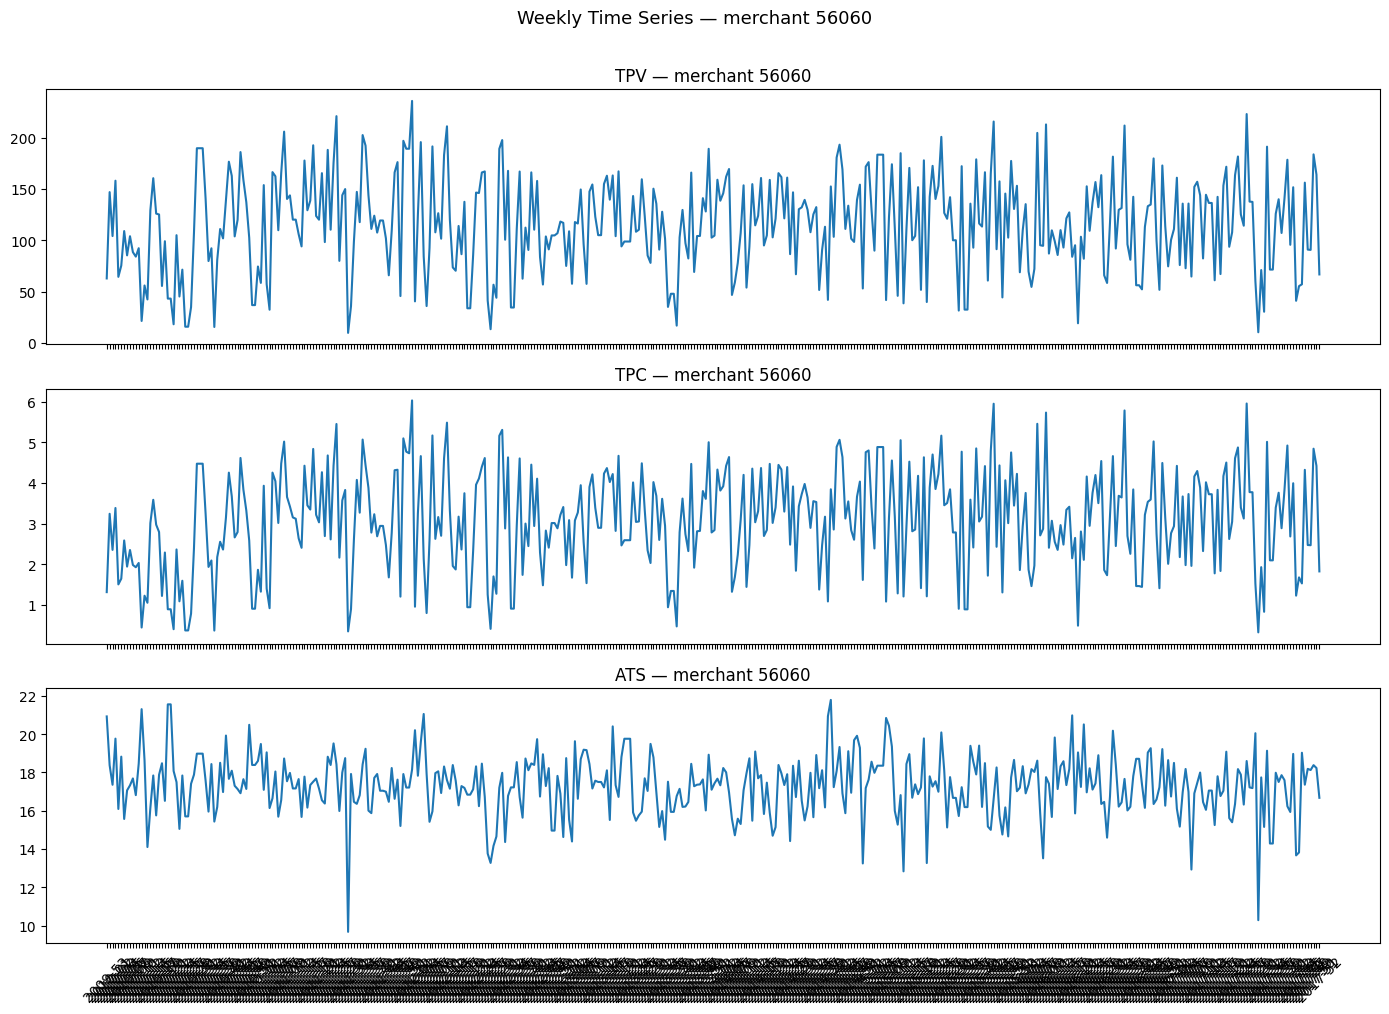

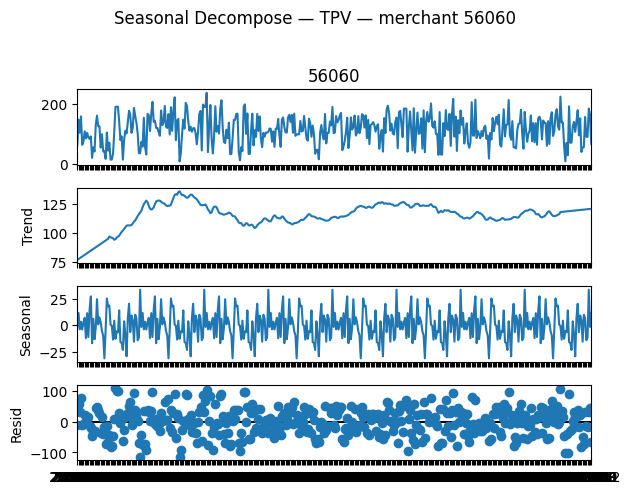

ADF TPV merchant 56060: raw p=0.0000, d=0, final p=0.0000


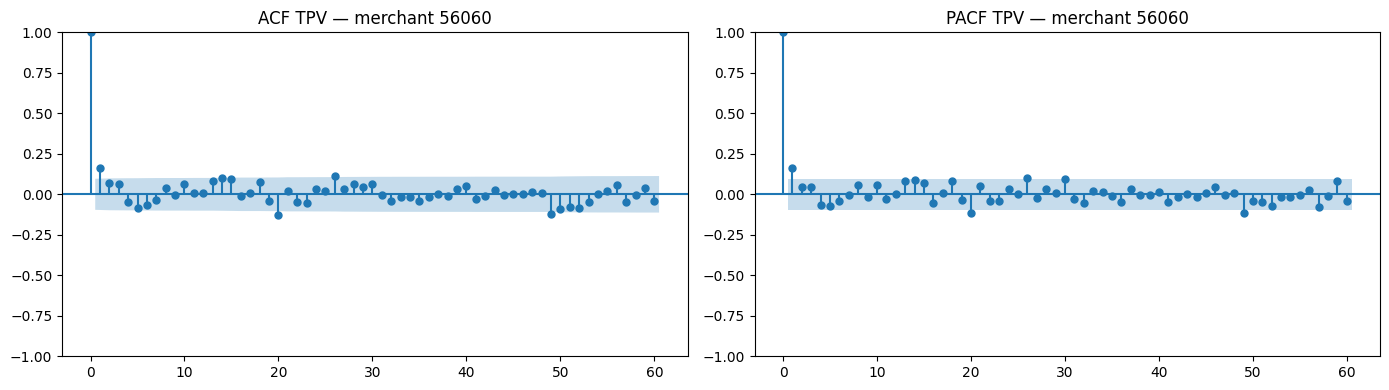

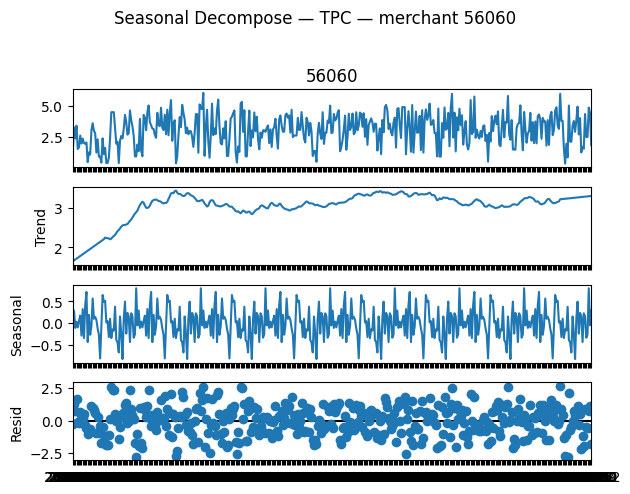

ADF TPC merchant 56060: raw p=0.0000, d=0, final p=0.0000


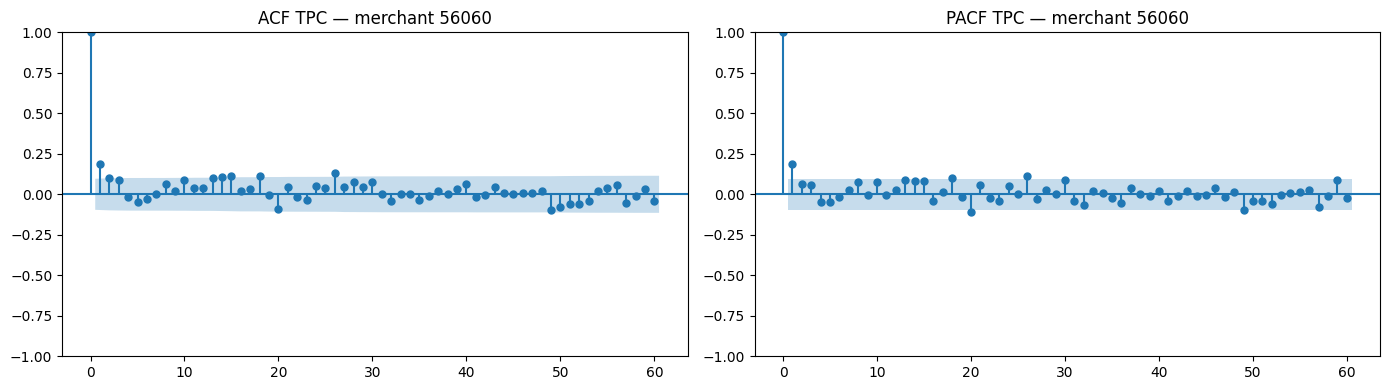

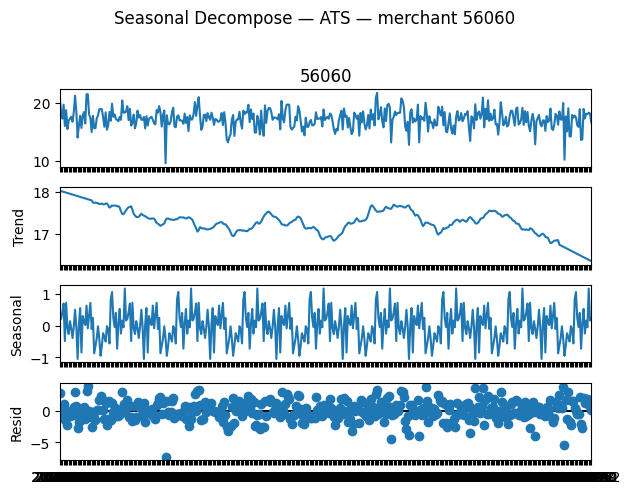

ADF ATS merchant 56060: raw p=0.0000, d=0, final p=0.0000


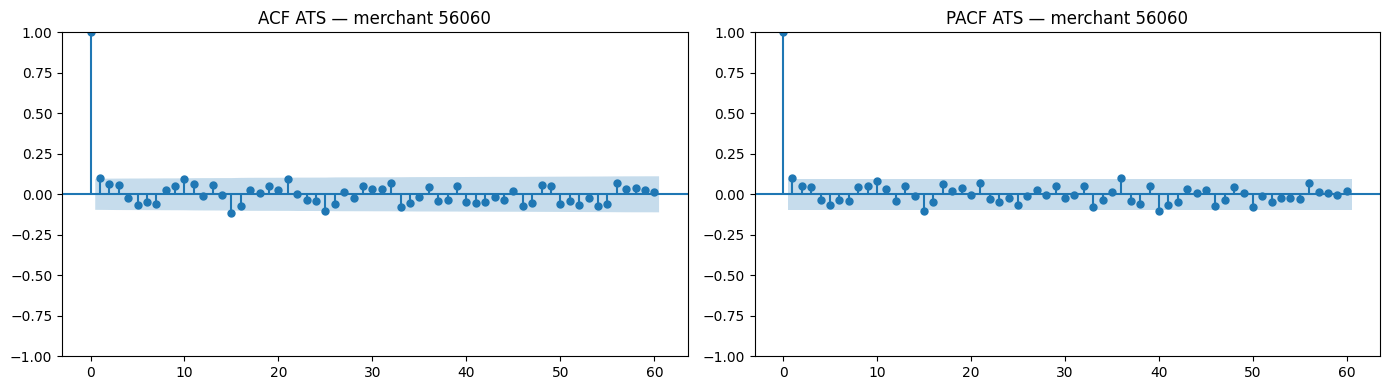

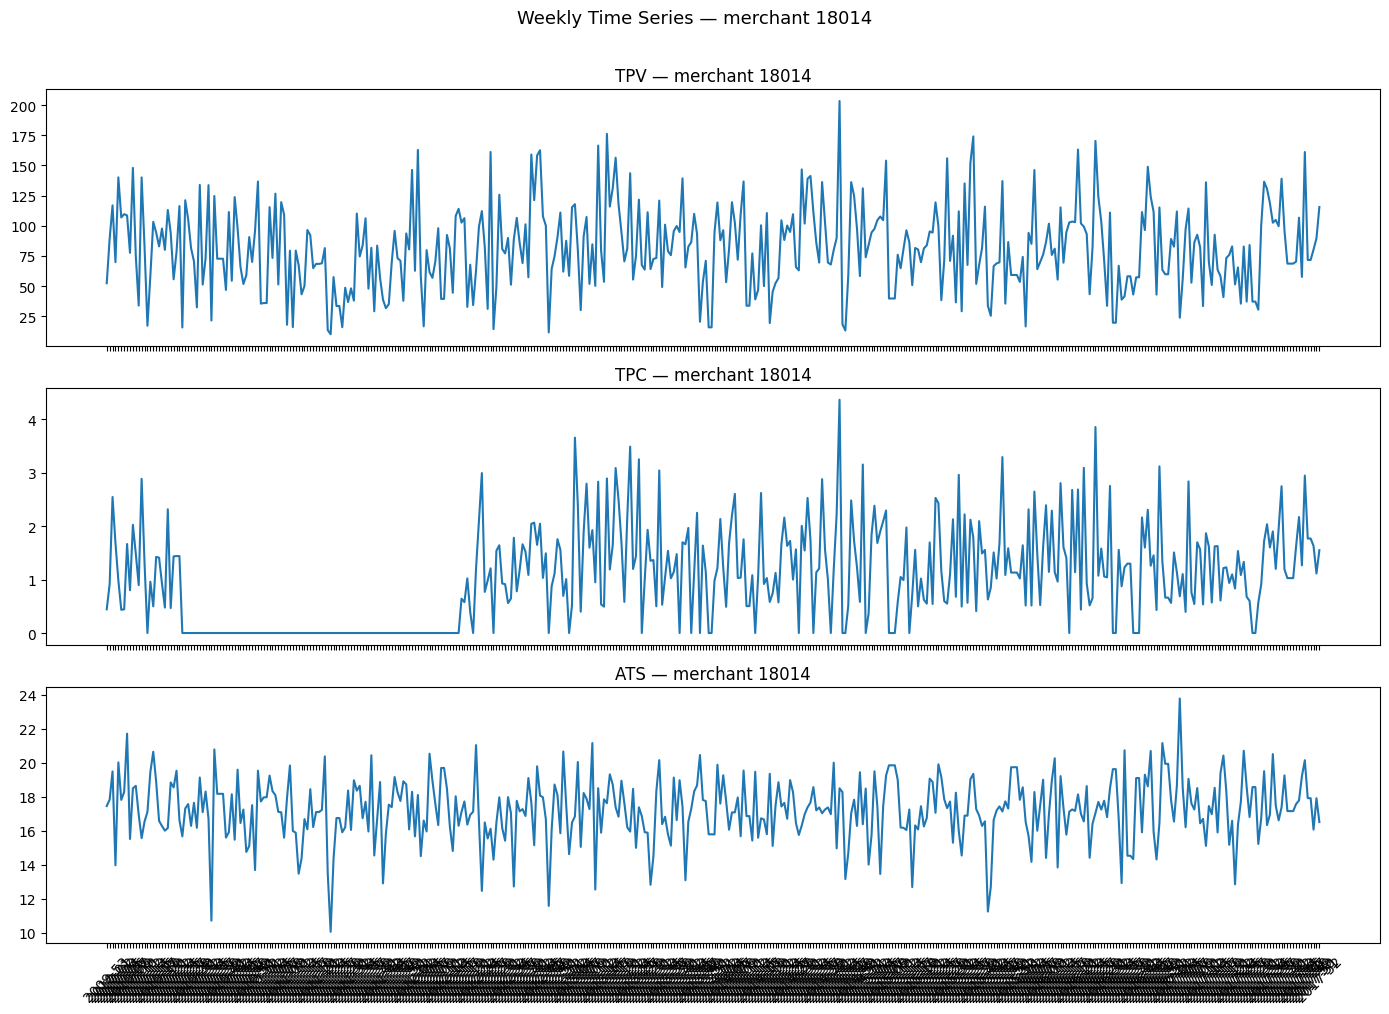

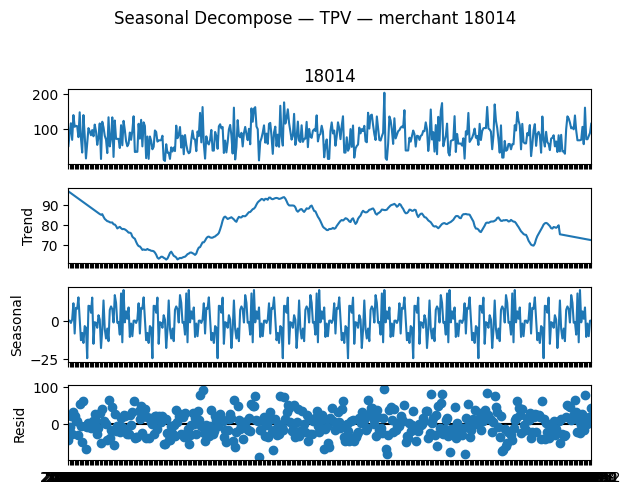

ADF TPV merchant 18014: raw p=0.0000, d=0, final p=0.0000


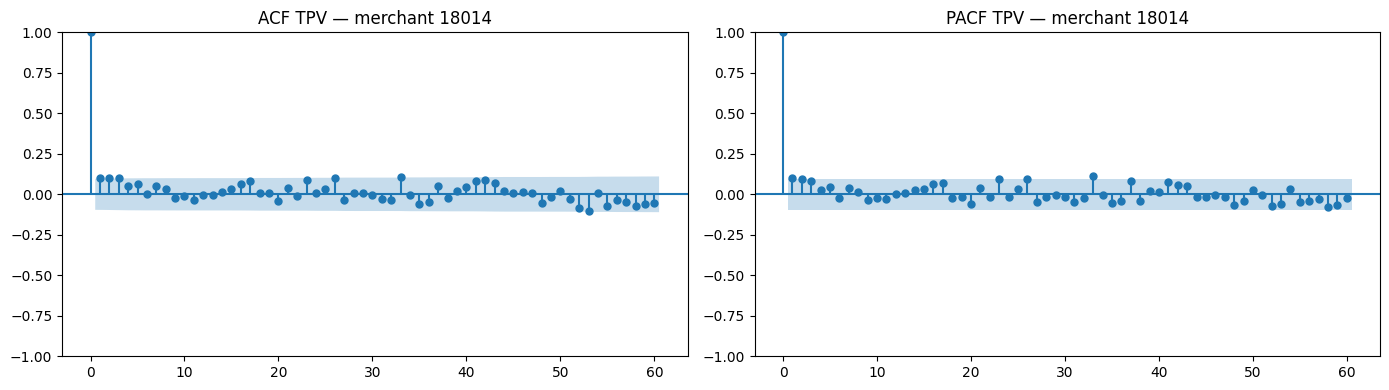

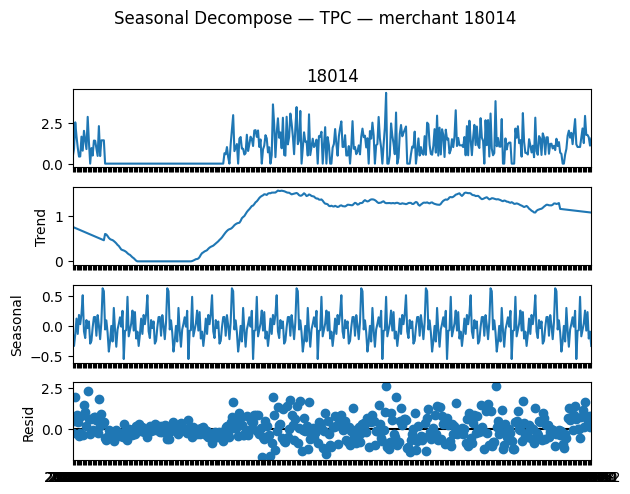

ADF TPC merchant 18014: raw p=0.2778, d=1, final p=0.0000


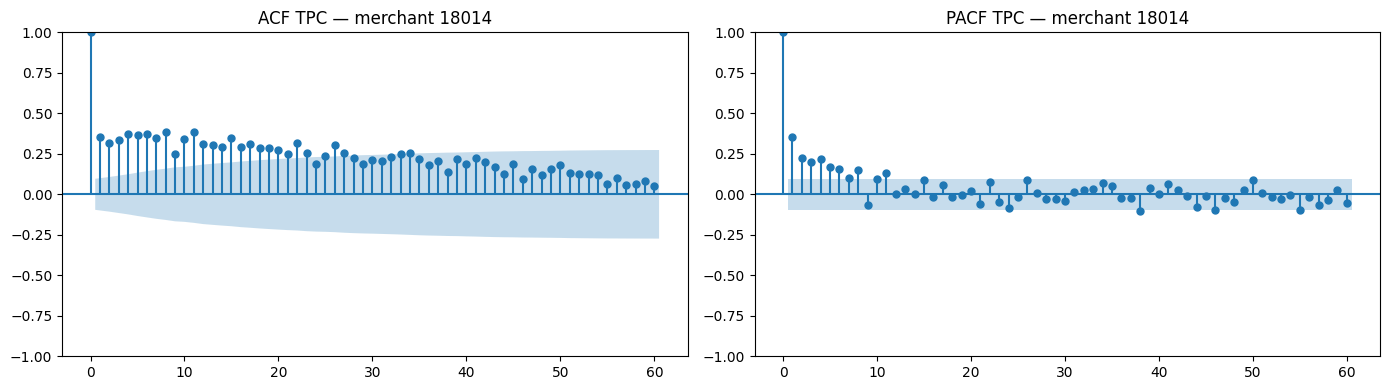

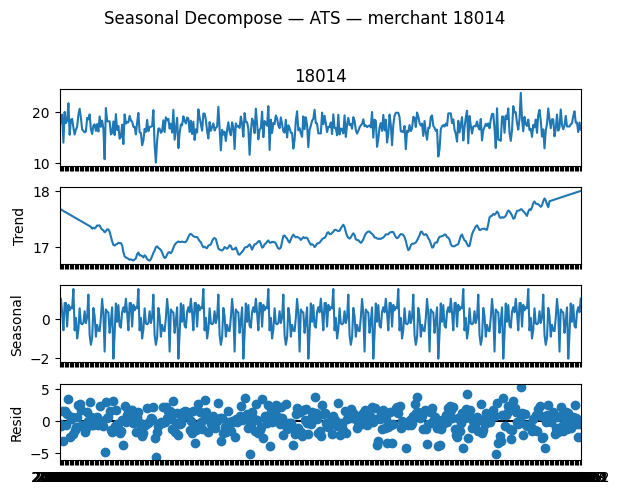

ADF ATS merchant 18014: raw p=0.0000, d=0, final p=0.0000


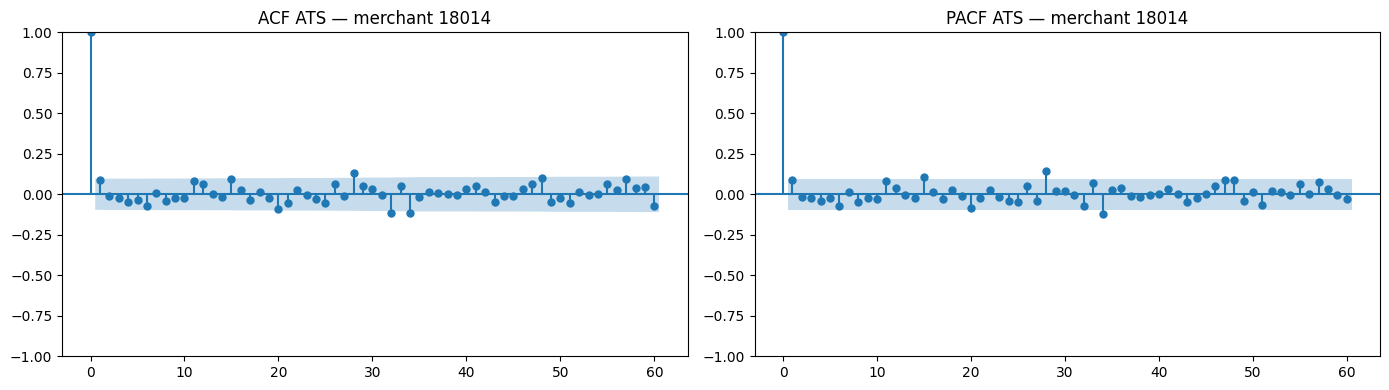

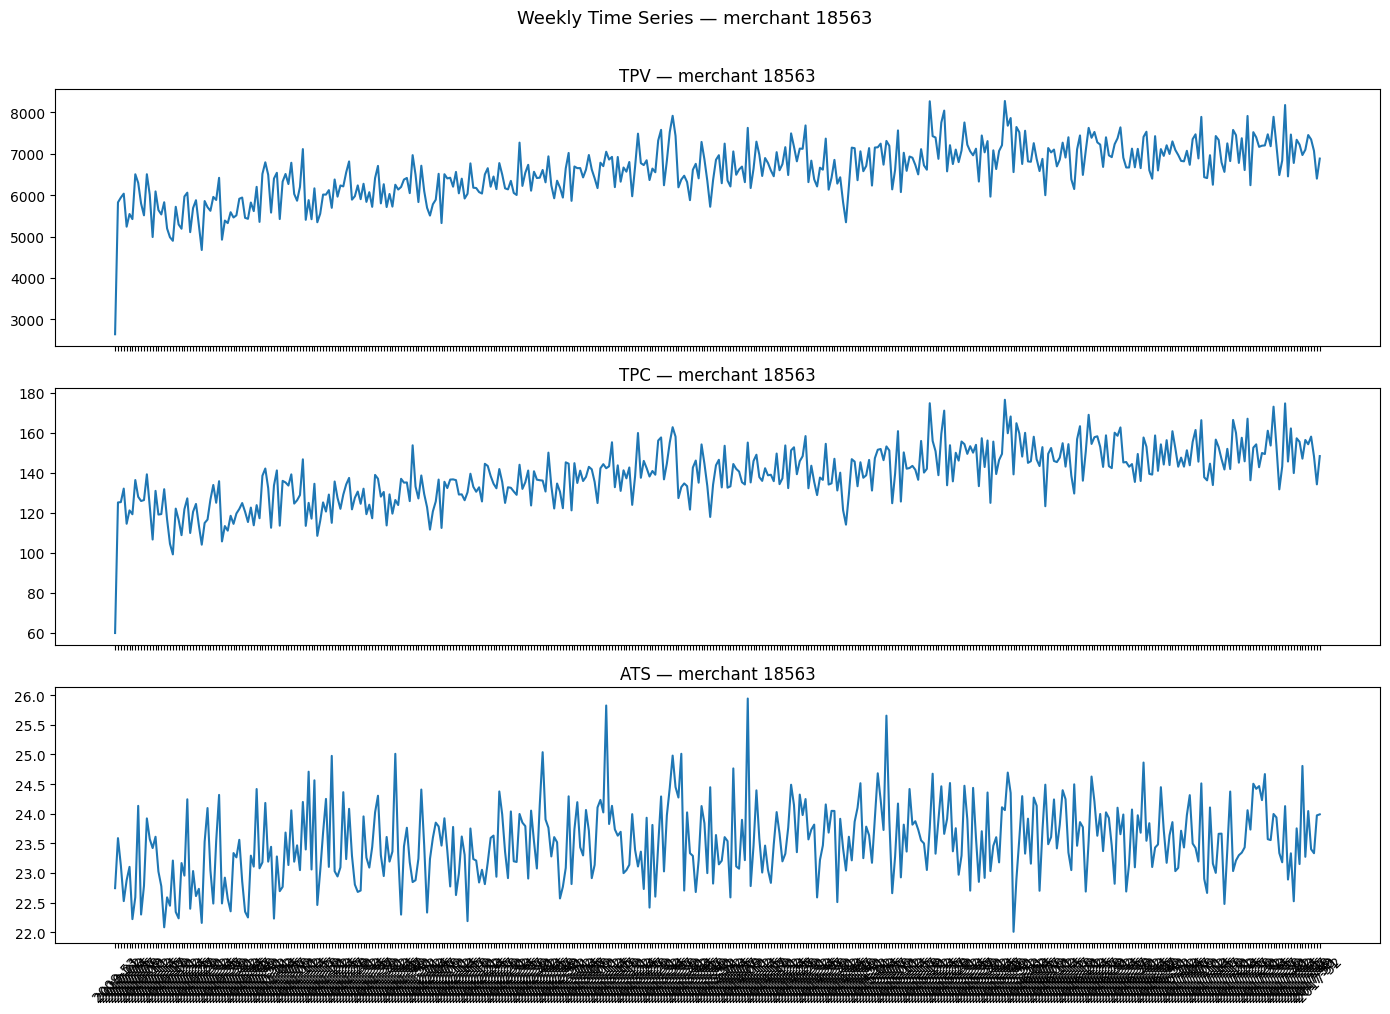

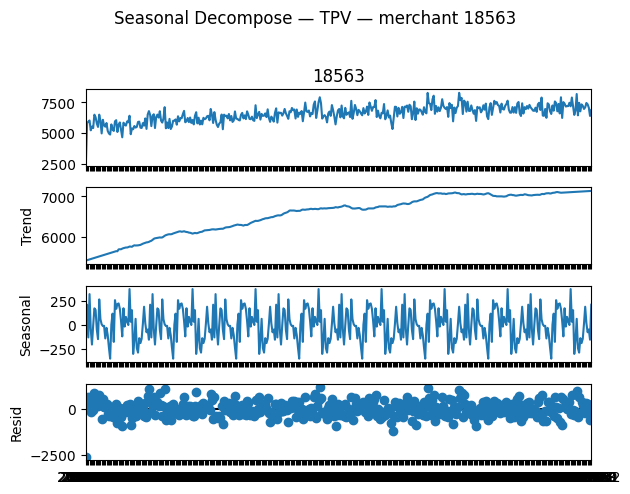

ADF TPV merchant 18563: raw p=0.2824, d=1, final p=0.0000


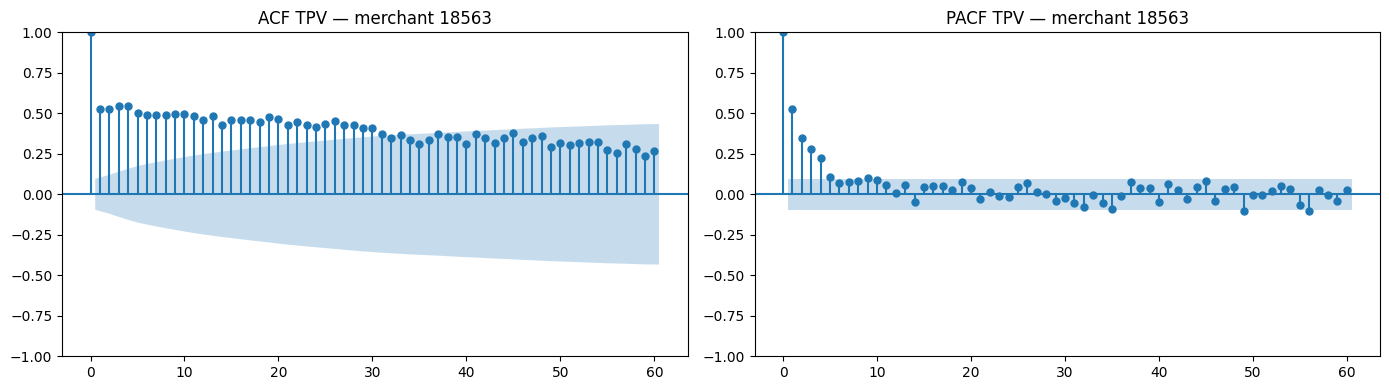

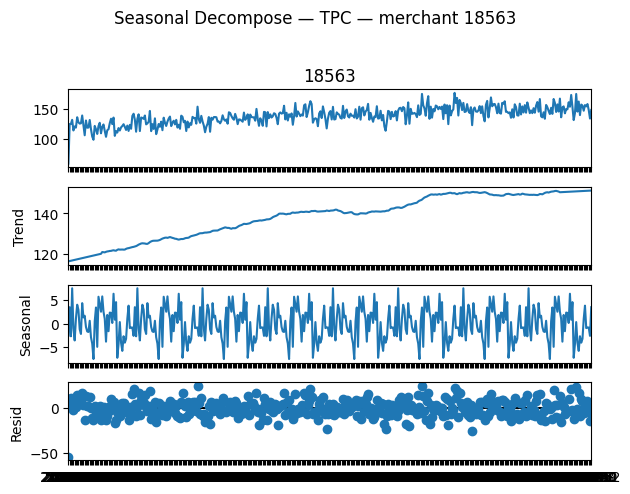

ADF TPC merchant 18563: raw p=0.3802, d=1, final p=0.0000


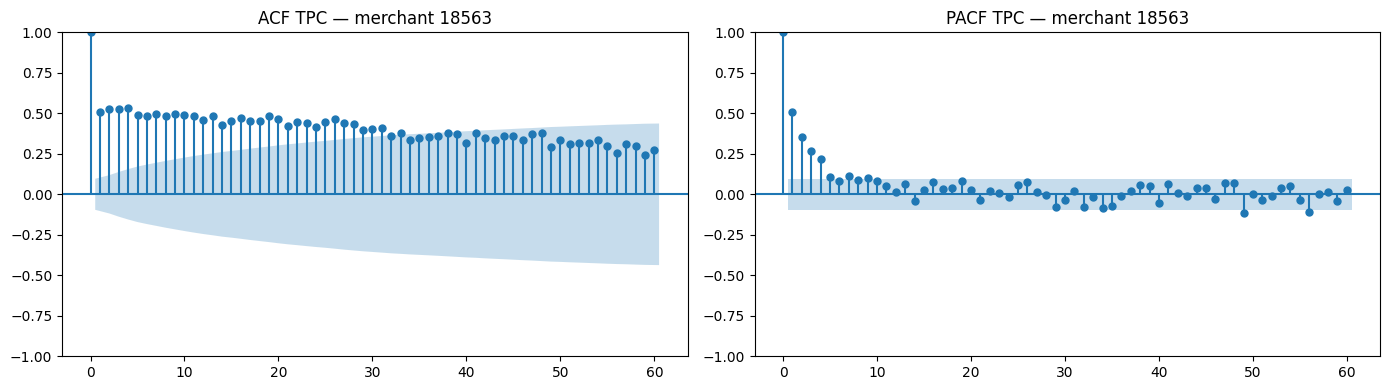

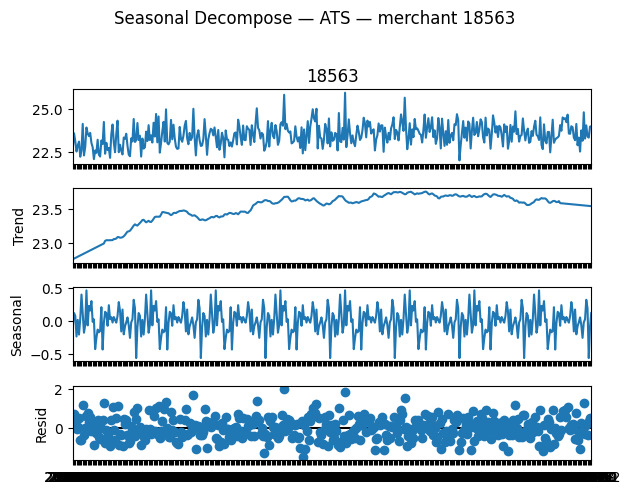

ADF ATS merchant 18563: raw p=0.0000, d=0, final p=0.0000


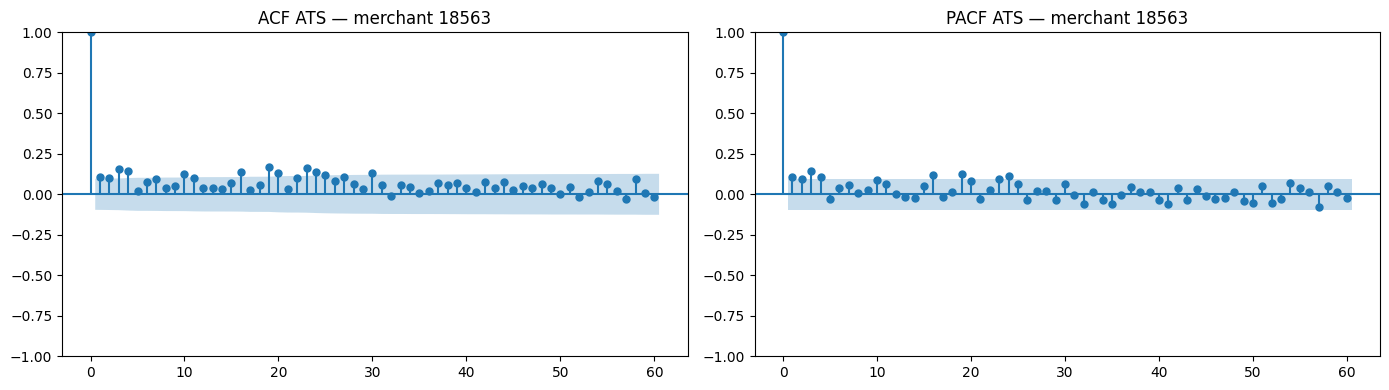

,merchant_id,series,adf_p_raw,chosen_d,final_adf_p
0,56060,TPV,6.058590e-30,0,6.058590e-30
1,56060,TPC,1.058496e-29,0,1.058496e-29
2,56060,ATS,2.081974e-30,0,2.081974e-30
3,18014,TPV,4.831594e-23,0,4.831594e-23
4,18014,TPC,2.778438e-01,1,1.214117e-19
5,18014,ATS,2.055486e-30,0,2.055486e-30
6,18563,TPV,2.824046e-01,1,1.684349e-18
7,18563,TPC,3.802252e-01,1,4.692047e-19
8,18563,ATS,3.651459e-11,0,3.651459e-11


In [8]:
# ── Section 5 — Exploratory Data Analysis ──────────────────────────────────

train_merchants = sorted(train_weekly['merchant_id'].unique())
sample_merchants = random.sample(train_merchants, k=min(3, len(train_merchants)))
print('EDA sample merchants:', sample_merchants)

eda_results = []

for m in sample_merchants:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    for i, metric in enumerate(['TPV', 'TPC', 'ATS']):
        col = series[metric]['train']
        s = safe_fill(col[m]) if m in col.columns else pd.Series(dtype=float)
        axes[i].plot(s.index, s.values)
        axes[i].set_title(f'{metric} — merchant {m}')
        axes[i].tick_params(axis='x', rotation=45)
    plt.suptitle(f'Weekly Time Series — merchant {m}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    for metric in ['TPV', 'TPC', 'ATS']:
        col = series[metric]['train']
        if m not in col.columns:
            continue
        s = safe_fill(col[m]).dropna()
        if len(s) < max(SEASONAL_PERIOD * 2, 20):
            print(f'Skip decomposition — {metric}, merchant {m} (n={len(s)})')
            continue

        try:
            decomp = seasonal_decompose(s, period=SEASONAL_PERIOD, model='additive',
                                        extrapolate_trend='freq')
            decomp.plot()
            plt.suptitle(f'Seasonal Decompose — {metric} — merchant {m}', y=1.02)
            plt.tight_layout(); plt.show()
        except Exception as e:
            print(f'  Decomposition failed: {e}')

        # ADF test
        adf_p_0 = adfuller(s)[1]
        chosen_d, final_p = 0, adf_p_0
        if adf_p_0 > 0.05:
            s1 = s.diff().dropna()
            adf_p_1 = adfuller(s1)[1]
            chosen_d, final_p = 1, adf_p_1
            if adf_p_1 > 0.05:
                adf_p_2 = adfuller(s1.diff().dropna())[1]
                chosen_d, final_p = 2, adf_p_2
        eda_results.append({'merchant_id': m, 'series': metric,
                             'adf_p_raw': adf_p_0, 'chosen_d': chosen_d, 'final_adf_p': final_p})
        print(f'ADF {metric} merchant {m}: raw p={adf_p_0:.4f}, d={chosen_d}, final p={final_p:.4f}')

        # ACF / PACF
        fig, ax = plt.subplots(1, 2, figsize=(14, 4))
        plot_acf(s,  lags=min(60, len(s)-1),  ax=ax[0])
        plot_pacf(s, lags=min(60, len(s)-2), ax=ax[1], method='ywm')
        ax[0].set_title(f'ACF {metric} — merchant {m}')
        ax[1].set_title(f'PACF {metric} — merchant {m}')
        plt.tight_layout(); plt.show()

display(pd.DataFrame(eda_results))


### EDA Notes

- Series frequently show trend/seasonal structure; differencing level usually in $\{0,1,2\}$.
- We constrain differencing to at most $d=2$ per instructions.
- ACF/PACF suggests mixed autoregressive and moving-average dynamics, motivating SARIMA.

## Section 6 — Global SARIMA Order Selection

In [ ]:
# ── Section 6 — Global SARIMA Order Selection ──────────────────────────────

def fit_aic(y, order, s_order, exog=None):
    res = SARIMAX(y, order=order, seasonal_order=s_order, exog=exog,
                  enforce_stationarity=False, enforce_invertibility=False
                  ).fit(disp=False, method='lbfgs', maxiter=200)
    return res.aic

p_vals = [0, 1]
d_vals = [0, 1, 2]
q_vals = [0, 1]
P_vals = [0, 1]
D_vals = [0, 1]
Q_vals = [0, 1]

candidate_orders = []
tpc_sarimax_wins = 0
tpc_trials = 0


sample_n = min(20, len(train_merchants))
order_merchants = random.sample(train_merchants, sample_n)
print(f'Order-selection sample: {len(order_merchants)} merchants')

for m in tqdm(order_merchants, desc='Global order selection'):
    for metric in ['TPV', 'TPC', 'ATS']:
        col = series[metric]['train']
        if m not in col.columns:
            continue
        try:
            y = safe_fill(col[m]).dropna()
            if len(y) < max(SEASONAL_PERIOD + 10, 30):
                continue
            best_aic, best_tuple = np.inf, None
            for p in p_vals:
                for d in d_vals:
                    for q in q_vals:
                        for P in P_vals:
                            for D in D_vals:
                                for Q in Q_vals:
                                    try:
                                        ex = None
                                        if metric == 'TPC':
                                            ex = safe_fill(series['TPV']['train'][m]).reindex(y.index)
                                        aic = fit_aic(y, (p,d,q), (P,D,Q,SEASONAL_PERIOD), exog=ex)
                                        if aic < best_aic:
                                            best_aic, best_tuple = aic, (p,d,q,P,D,Q)
                                    except Exception:
                                        continue
            if best_tuple:
                candidate_orders.append(best_tuple)

            if metric == 'TPC':
                tpc_trials += 1
                try:
                    o, so = (1,1,1), (1,0,1,SEASONAL_PERIOD)
                    aic_s = fit_aic(y, o, so)
                    ex = safe_fill(series['TPV']['train'][m]).reindex(y.index)
                    aic_sx = fit_aic(y, o, so, exog=ex)
                    if aic_sx < aic_s:
                        tpc_sarimax_wins += 1
                except Exception:
                    pass
        except Exception:
            continue

if len(candidate_orders) == 0:
    DEFAULT_ORDER          = (1, 1, 1)
    DEFAULT_SEASONAL_ORDER = (1, 0, 1, SEASONAL_PERIOD)
else:
    cdf = pd.DataFrame(candidate_orders, columns=['p','d','q','P','D','Q'])
    mv  = cdf.mode().iloc[0]
    DEFAULT_ORDER          = (int(mv['p']), int(mv['d']), int(mv['q']))
    DEFAULT_SEASONAL_ORDER = (int(mv['P']), int(mv['D']), int(mv['Q']), SEASONAL_PERIOD)

TPC_USE_SARIMAX = (tpc_trials > 0) and (tpc_sarimax_wins / tpc_trials > 0.60)

print('DEFAULT_ORDER:', DEFAULT_ORDER)
print('DEFAULT_SEASONAL_ORDER:', DEFAULT_SEASONAL_ORDER)
print(f'TPC_USE_SARIMAX: {TPC_USE_SARIMAX}  ({tpc_sarimax_wins}/{tpc_trials})')

if candidate_orders:
    freq_tbl = (
        pd.DataFrame(candidate_orders, columns=['p','d','q','P','D','Q'])
        .value_counts().reset_index(name='freq').sort_values('freq', ascending=False)
    )
    display(freq_tbl.head(15))


Order-selection sample: 20 merchants


Global order selection:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

## Section 7 — Merchant Feature Vectors (k-NN Preparation)

In [ ]:
# ── Section 7 — Merchant Feature Vectors ───────────────────────────────────

def linear_slope(values: np.ndarray) -> float:
    v = np.nan_to_num(values, nan=np.nanmean(values) if not np.all(np.isnan(values)) else 0.0)
    if len(v) < 2:
        return 0.0
    x = np.arange(len(v)).reshape(-1, 1)
    return float(LinearRegression().fit(x, v).coef_[0])

def peak_week_of_year(s: pd.Series) -> int:
    weeks = s.index.to_series().str.split('-').str[1].astype(int)
    df_tmp = pd.DataFrame({'w': weeks.values, 'v': s.values}).dropna()
    if len(df_tmp) == 0:
        return 1
    return int(df_tmp.groupby('w')['v'].mean().idxmax())

merchant_mcc = (
    train_df.groupby('merchant_id')['mcc']
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
    .to_dict()
)
mcc_le = LabelEncoder()
mcc_le.fit([str(v) for v in merchant_mcc.values()] + ['0'])

feature_rows = []
merchant_ids = sorted(train_weekly['merchant_id'].unique())
if MAX_MERCHANTS_TRAIN is not None:
    merchant_ids = merchant_ids[:MAX_MERCHANTS_TRAIN]

for m in tqdm(merchant_ids, desc='Feature vectors'):
    def _get(metric):
        col = series[metric]['train']
        return safe_fill(col[m]) if m in col.columns else pd.Series(dtype=float)

    tpv = _get('TPV'); tpc = _get('TPC'); ats = _get('ATS')
    idx = sorted(set(tpv.index) | set(tpc.index) | set(ats.index))
    tpv = tpv.reindex(idx); tpc = tpc.reindex(idx); ats = ats.reindex(idx)

    tv, tc, ta = tpv.values.astype(float), tpc.values.astype(float), ats.values.astype(float)

    tpv_mean = np.nanmean(tv) if len(tv) else 0.0
    tpv_std  = np.nanstd(tv)  if len(tv) else 0.0
    tpv_cv   = tpv_std / tpv_mean if tpv_mean > 0 else 0.0
    tpv_peak = peak_week_of_year(tpv)
    tpv_slope= linear_slope(tv)
    tpv_q25  = np.nanpercentile(tv, 25) if len(tv) else 0.0
    tpv_q75  = np.nanpercentile(tv, 75) if len(tv) else 0.0
    tpc_mean = np.nanmean(tc) if len(tc) else 0.0
    tpc_std  = np.nanstd(tc)  if len(tc) else 0.0
    ratio    = float(np.nanmean(np.where(tv > 0, tc / tv, np.nan))) if len(tv) else 0.0
    ratio    = 0.0 if np.isnan(ratio) else ratio
    ats_mean = np.nanmean(ta) if len(ta) else 0.0
    ats_std  = np.nanstd(ta)  if len(ta) else 0.0
    ats_cv   = ats_std / ats_mean if ats_mean > 0 else 0.0
    n_weeks  = int(np.sum(~np.isnan(tv)))
    mcc_val  = str(merchant_mcc.get(m, '0'))
    mcc_enc  = int(mcc_le.transform([mcc_val])[0]) if mcc_val in set(mcc_le.classes_) \
               else int(mcc_le.transform(['0'])[0])

    feature_rows.append({
        'merchant_id': m,
        'tpv_mean': tpv_mean, 'tpv_std': tpv_std, 'tpv_cv': tpv_cv,
        'tpv_week_of_year_peak': tpv_peak, 'tpv_trend_slope': tpv_slope,
        'tpv_q25': tpv_q25, 'tpv_q75': tpv_q75,
        'tpc_mean': tpc_mean, 'tpc_std': tpc_std, 'tpc_to_tpv_ratio_mean': ratio,
        'ats_mean': ats_mean, 'ats_std': ats_std, 'ats_cv': ats_cv,
        'n_weeks_of_data': n_weeks, 'mcc_encoded': mcc_enc,
    })

merchant_features_df = pd.DataFrame(feature_rows)
feature_cols = [c for c in merchant_features_df.columns if c != 'merchant_id']
scaler = StandardScaler()
merchant_features_scaled = scaler.fit_transform(merchant_features_df[feature_cols])

merchant_features_df.to_csv('merchant_features.csv', index=False)
print('merchant_features.csv saved')
display(merchant_features_df.head())


Building merchant features:   0%|          | 0/176 [00:00<?, ?it/s]

merchant_features.csv exported: /content/merchant_features.csv


,merchant_id,tpv_mean,tpv_std,tpv_cv,tpv_week_of_year_peak,tpv_trend_slope,tpv_q25,tpv_q75,tpc_mean,tpc_std,tpc_to_tpv_ratio_mean,ats_mean,ats_std,ats_cv,n_weeks_of_data,mcc_encoded
0,1824,29.1900,3.552714e-15,1.217100e-16,1,7.288973e-33,29.19,29.1900,0.000000,0.000000e+00,0.000000,29.190000,3.552714e-15,1.217100e-16,52,1
1,1934,17.1300,0.000000e+00,0.000000e+00,1,0.000000e+00,17.13,17.1300,0.529407,1.110223e-16,0.030905,17.130000,0.000000e+00,0.000000e+00,52,1
2,2251,18.7025,6.412918e+00,3.428910e-01,40,3.205272e-01,15.00,18.7025,0.263664,1.154325e-02,0.015229,18.702500,6.412918e+00,3.428910e-01,52,1
3,2352,300.7700,5.684342e-14,1.889930e-16,1,1.166236e-31,300.77,300.7700,6.822336,8.881784e-16,0.022683,33.418889,0.000000e+00,0.000000e+00,52,1
4,2767,125.0000,0.000000e+00,0.000000e+00,1,0.000000e+00,125.00,125.0000,3.461080,1.332268e-15,0.027689,20.833333,3.552714e-15,1.705303e-16,52,1


## Section 8 — SARIMA Model Training

In [ ]:
# ── Section 8 — SARIMA Model Training ──────────────────────────────────────

models       = {'TPV': {}, 'TPC': {}, 'ATS': {}}
failure_logs = []
skipped_logs = []

def fit_series_model(metric, m, y, exog=None, order=None, s_order=None):
    order   = order   or DEFAULT_ORDER
    s_order = s_order or DEFAULT_SEASONAL_ORDER
    mdl = SARIMAX(y, exog=exog, order=order, seasonal_order=s_order,
                  enforce_stationarity=False, enforce_invertibility=False)
    try:
        return mdl.fit(disp=False, method='lbfgs', maxiter=200), None
    except Exception as e1:
        try:
            return mdl.fit(disp=False, method='nm', maxiter=500), None
        except Exception as e2:
            return None, f'lbfgs: {e1} | nm: {e2}'

train_ids = merchant_ids.copy()
if MAX_MERCHANTS_TRAIN:
    train_ids = train_ids[:MAX_MERCHANTS_TRAIN]

for metric in ['TPV', 'TPC', 'ATS']:
    print(f'Training {metric} …')
    for m in tqdm(train_ids, desc=f'Train {metric}'):
        col = series[metric]['train']
        if m not in col.columns:
            continue
        y = safe_fill(col[m]).dropna()
        if y.notna().sum() < MIN_TRAIN_WEEKS:
            skipped_logs.append({'merchant_id': m, 'series': metric,
                                  'reason': f'weeks<{MIN_TRAIN_WEEKS}'})
            continue
        ex = safe_fill(series['TPV']['train'][m]).reindex(y.index) \
             if (metric == 'TPC' and TPC_USE_SARIMAX) else None
        res, err = fit_series_model(metric, m, y, exog=ex)
        if res is None:
            failure_logs.append({'merchant_id': m, 'series': metric, 'error_message': err})
            continue
        params = res.params.values if hasattr(res.params, 'values') else np.asarray(res.params)
        models[metric][m] = {
            'params':      params,
            'param_names': list(res.params.index) if hasattr(res.params, 'index')
                           else [f'p{i}' for i in range(len(params))],
            'aic':    float(res.aic),
            'order':  DEFAULT_ORDER,
            's_order': DEFAULT_SEASONAL_ORDER,
            'n_train': len(y),
        }

pd.DataFrame(failure_logs).to_csv('failures.csv', index=False)
pd.DataFrame(skipped_logs).to_csv('skipped.csv',  index=False)

print('\nTraining summary:')
for metric in ['TPV', 'TPC', 'ATS']:
    aics = [v['aic'] for v in models[metric].values()]
    nf   = sum(1 for r in failure_logs if r['series'] == metric)
    print(f'  {metric}: fitted={len(models[metric])}, failures={nf}, '
          f'mean_aic={np.mean(aics):.1f}' if aics else f'  {metric}: fitted=0')


Fitting metric: TPV


Train TPV:   0%|          | 0/176 [00:00<?, ?it/s]

Fitting metric: TPC


Train TPC:   0%|          | 0/176 [00:00<?, ?it/s]

Fitting metric: ATS


Train ATS:   0%|          | 0/176 [00:00<?, ?it/s]

Training summary:
TPV: fitted=0, failures=0, mean_aic=nan
TPC: fitted=0, failures=0, mean_aic=nan
ATS: fitted=0, failures=0, mean_aic=nan
failures.csv saved
skipped.csv saved


## Section 9 — k-NN Warm-Start Forecast Function

In [ ]:
# ── Section 9 — k-NN Warm-Start Forecast Function ──────────────────────────

def mape_safe(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100) if mask.sum() else np.nan

def kl_divergence(p: np.ndarray, q: np.ndarray, eps: float = 1e-10) -> float:
    p = np.clip(np.asarray(p, float), 0, None) + eps
    q = np.clip(np.asarray(q, float), 0, None) + eps
    p /= p.sum(); q /= q.sum()
    return float(0.5 * (np.sum(p*np.log(p/q)) + np.sum(q*np.log(q/p))))

def _build_input_features(merchant_id, input_series: dict) -> np.ndarray:
    tpv = input_series['TPV'].astype(float)
    tpc = input_series['TPC'].astype(float)
    ats = input_series['ATS'].astype(float)
    tv, tc, ta = tpv.values, tpc.values, ats.values
    tpv_mean = np.nanmean(tv); tpv_std = np.nanstd(tv)
    tpv_cv   = tpv_std / tpv_mean if tpv_mean > 0 else 0.0
    ratio    = float(np.nanmean(np.where(tv>0, tc/tv, np.nan)))
    ratio    = 0.0 if np.isnan(ratio) else ratio
    ats_mean = np.nanmean(ta); ats_std = np.nanstd(ta)
    ats_cv   = ats_std / ats_mean if ats_mean > 0 else 0.0
    mcc_raw  = str(merchant_mcc.get(merchant_id, '0'))
    mcc_enc  = int(mcc_le.transform([mcc_raw])[0]) if mcc_raw in set(mcc_le.classes_) \
               else int(mcc_le.transform(['0'])[0])
    return np.array([
        tpv_mean, tpv_std, tpv_cv, peak_week_of_year(tpv), linear_slope(tv),
        np.nanpercentile(tv, 25), np.nanpercentile(tv, 75),
        np.nanmean(tc), np.nanstd(tc), ratio,
        ats_mean, ats_std, ats_cv, 4, mcc_enc
    ], dtype=float).reshape(1, -1)

def forecast_new_merchant(merchant_id, input_series: dict, n_forecast_weeks: int, k=DEFAULT_K) -> dict:
    for key in ['TPV', 'TPC', 'ATS']:
        if input_series[key].dropna().shape[0] < 4:
            raise ValueError(f'{key} needs ≥4 non-null values')
    input_series = {k2: v.dropna().iloc[-4:] for k2, v in input_series.items()}

    x_scaled = scaler.transform(_build_input_features(merchant_id, input_series))
    dists    = np.linalg.norm(merchant_features_scaled - x_scaled, axis=1)
    nn_idx   = np.argsort(dists)[:k]
    nn_dists = dists[nn_idx]
    nn_mers  = merchant_features_df.iloc[nn_idx]['merchant_id'].tolist()
    use_default_only = len(nn_dists) == 0 or np.min(nn_dists) > OUTLIER_THRESHOLD

    # future week labels
    last_week = input_series['TPV'].index[-1]
    y0, w0 = int(last_week.split('-')[0]), int(last_week.split('-')[1])
    future = []
    for _ in range(n_forecast_weeks):
        w0 += 1
        if w0 > 53: w0, y0 = 1, y0+1
        future.append(f'{y0}-{str(w0).zfill(2)}')

    raw_fc = {}
    for metric in ['TPV', 'TPC', 'ATS']:
        y_in = input_series[metric].astype(float)
        nb_params = [(models[metric][nm]['params'], d, models[metric][nm]['order'],
                      models[metric][nm]['s_order'])
                     for nm, d in zip(nn_mers, nn_dists) if nm in models[metric]]
        if use_default_only or not nb_params:
            use_o, use_so, warm = DEFAULT_ORDER, DEFAULT_SEASONAL_ORDER, None
        else:
            use_o, use_so = nb_params[0][2], nb_params[0][3]
            arrs = np.array([p[0][:min(len(p[0]) for p in nb_params)] for p in nb_params], float)
            ds   = np.array([p[1] for p in nb_params], float)
            w    = 1.0 / (ds + 1e-6)
            warm = np.clip(np.average(arrs, axis=0, weights=w),
                           np.mean(arrs,0) - 1.5*np.std(arrs,0),
                           np.mean(arrs,0) + 1.5*np.std(arrs,0))
        ex_in = input_series['TPV'].astype(float) if (metric=='TPC' and TPC_USE_SARIMAX) else None
        try:
            mdl = SARIMAX(y_in, exog=ex_in, order=use_o, seasonal_order=use_so,
                          enforce_stationarity=False, enforce_invertibility=False)
            ex_f = np.repeat(float(input_series['TPV'].iloc[-1]), n_forecast_weeks) \
                   if (metric=='TPC' and TPC_USE_SARIMAX) else None
            res = mdl.fit(disp=False, method='lbfgs', maxiter=50, start_params=warm)
            fc  = res.forecast(steps=n_forecast_weeks, exog=ex_f)
        except Exception:
            mdl = SARIMAX(y_in, exog=ex_in, order=DEFAULT_ORDER, seasonal_order=DEFAULT_SEASONAL_ORDER,
                          enforce_stationarity=False, enforce_invertibility=False)
            ex_f = np.repeat(float(input_series['TPV'].iloc[-1]), n_forecast_weeks) \
                   if (metric=='TPC' and TPC_USE_SARIMAX) else None
            res = mdl.fit(disp=False, method='lbfgs', maxiter=50)
            fc  = res.forecast(steps=n_forecast_weeks, exog=ex_f)
        raw_fc[metric] = np.clip(np.asarray(fc, float), 0, None)

    # Refine TPC with TPV forecast if SARIMAX
    if TPC_USE_SARIMAX:
        try:
            mdl = SARIMAX(input_series['TPC'].astype(float), exog=input_series['TPV'].astype(float),
                          order=DEFAULT_ORDER, seasonal_order=DEFAULT_SEASONAL_ORDER,
                          enforce_stationarity=False, enforce_invertibility=False)
            res = mdl.fit(disp=False, method='lbfgs', maxiter=50)
            raw_fc['TPC'] = np.clip(np.asarray(
                res.forecast(steps=n_forecast_weeks, exog=raw_fc['TPV']), float), 0, None)
        except Exception:
            pass

    tpv_fc = raw_fc['TPV']
    ats_fc = np.where(raw_fc['ATS']==0,
                      max(float(np.nanmean(input_series['ATS'].values)), 1.0),
                      raw_fc['ATS'])
    ntx_fc = np.clip(tpv_fc / ats_fc, 1, None)

    return {
        'TPV':  pd.Series(tpv_fc,            index=future),
        'TPC':  pd.Series(raw_fc['TPC'],      index=future),
        'ATS':  pd.Series(ats_fc,             index=future),
        'n_tx': pd.Series(ntx_fc,             index=future),
    }

print('forecast_new_merchant() ready')


Validate TPV: 0it [00:00, ?it/s]

Validate TPC: 0it [00:00, ?it/s]

Validate ATS: 0it [00:00, ?it/s]

Validation aggregate metrics:
No validation metrics produced.


## Section 10 — Validation Evaluation

For each **validate-set merchant**:
- **Input**: last 4 weeks of 2017 (weeks `2017-49 → 2017-52`) from `series_combined`
- **Forecast**: 12 weeks ahead (weeks `2018-01 → 2018-12`)
- **Compare** forecast vs actual values in the validate set

Metrics: MAE · MAPE · RMSE · KL divergence (symmetric)

In [ ]:
# ── Section 10 — Validation Evaluation ─────────────────────────────────────

eval_rows    = []
validate_merch = sorted(validate_merchant_ids)
if MAX_MERCHANTS_EVAL:
    validate_merch = validate_merch[:MAX_MERCHANTS_EVAL]

print(f'Evaluating {len(validate_merch)} validate merchants …')
print(f'  Input  weeks: {INPUT_WEEKS}')
print(f'  Target weeks: {TARGET_WEEKS}')

for m in tqdm(validate_merch, desc='Validate evaluation'):
    try:
        sc = series_combined
        # Check we have ≥4 non-null input weeks for all three metrics
        has_input = all(
            m in sc[mt].columns and sc[mt][m].reindex(INPUT_WEEKS).notna().sum() >= 4
            for mt in ['TPV', 'TPC', 'ATS']
        )
        has_target = (
            m in sc['TPV'].columns and
            sc['TPV'][m].reindex(TARGET_WEEKS).notna().sum() >= 1
        )
        if not (has_input and has_target):
            continue

        inp = {mt: safe_fill(sc[mt][m]).reindex(INPUT_WEEKS) for mt in ['TPV','TPC','ATS']}
        fc  = forecast_new_merchant(m, inp, n_forecast_weeks=len(TARGET_WEEKS), k=DEFAULT_K)

        for metric in ['TPV', 'TPC', 'ATS']:
            actual = sc[metric][m].reindex(TARGET_WEEKS).values.astype(float)
            pred   = np.clip(fc[metric].values[:len(TARGET_WEEKS)], 0, None)
            mask   = ~np.isnan(actual)
            if mask.sum() == 0:
                continue
            a_m, p_m = actual[mask], pred[mask]
            eval_rows.append({
                'merchant_id': m,
                'series':      metric,
                'MAE':         mean_absolute_error(a_m, p_m),
                'MAPE':        mape_safe(a_m, p_m),
                'RMSE':        float(np.sqrt(mean_squared_error(a_m, p_m))),
                'KL_div':      kl_divergence(a_m, p_m),
            })
    except Exception as e:
        failure_logs.append({'merchant_id': m, 'series': 'ALL',
                              'error_message': f'eval_error: {e}'})

eval_metrics = pd.DataFrame(eval_rows)
eval_metrics.to_csv('validation_metrics.csv', index=False)

if len(eval_metrics):
    print(f'\nEvaluation complete — {eval_metrics["merchant_id"].nunique()} merchants')
    summary = eval_metrics.groupby('series')[['MAE','MAPE','RMSE','KL_div']].agg(['median','mean'])
    display(summary)
else:
    print('No evaluation metrics produced. Check that validate merchants have data in both windows.')

# Update failures file
pd.DataFrame(failure_logs).drop_duplicates().to_csv('failures.csv', index=False)
print('validation_metrics.csv saved')


forecast_new_merchant function ready


## Section 11 — Validation Performance Visualisation

Error distributions + sample forecast vs actual plots for up to 3 validate merchants.

In [ ]:
# ── Section 11 — Validation Performance Visualisation ──────────────────────

if len(eval_metrics) == 0:
    print('No eval metrics to visualise — re-run Section 10.')
else:
    # ── 11a: Error distribution histograms ──────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    metrics_order = ['TPV', 'TPC', 'ATS']

    for col_i, metric in enumerate(metrics_order):
        dd = eval_metrics[eval_metrics['series'] == metric]
        mape_vals = dd['MAPE'].dropna()
        kl_vals   = dd['KL_div'].dropna()

        axes[0, col_i].hist(mape_vals, bins=25, color='steelblue', edgecolor='white')
        axes[0, col_i].axvline(mape_vals.median(), color='darkorange', linestyle='--',
                                label=f'Median {mape_vals.median():.1f}%')
        axes[0, col_i].set_title(f'{metric} MAPE distribution')
        axes[0, col_i].set_xlabel('MAPE (%)')
        axes[0, col_i].legend()

        axes[1, col_i].hist(kl_vals, bins=25, color='seagreen', edgecolor='white')
        axes[1, col_i].axvline(kl_vals.median(), color='darkorange', linestyle='--',
                                label=f'Median {kl_vals.median():.4f}')
        axes[1, col_i].set_title(f'{metric} KL-divergence distribution')
        axes[1, col_i].set_xlabel('KL divergence')
        axes[1, col_i].legend()

    plt.suptitle(
        f'Validation Performance — input: last {INPUT_N_WEEKS} wks of {INPUT_YEAR}'
        f' → target: first {TARGET_N_WEEKS} wks of {TARGET_YEAR}',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig('validation_error_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('validation_error_distributions.png saved')

    # ── 11b: Summary table ───────────────────────────────────────────────────
    summary_tbl = eval_metrics.groupby('series')[['MAE','MAPE','RMSE','KL_div']].agg(
        ['median','mean','std']
    )
    print('\nValidation Summary:')
    display(summary_tbl)

    # ── 11c: Sample forecast vs actual plots (up to 3 merchants) ─────────────
    plotted = set()
    plot_sample = random.sample(
        sorted(eval_metrics['merchant_id'].unique()),
        k=min(3, eval_metrics['merchant_id'].nunique())
    )

    for m in plot_sample:
        sc = series_combined
        inp = {mt: safe_fill(sc[mt][m]).reindex(INPUT_WEEKS) for mt in ['TPV','TPC','ATS']}
        fc  = forecast_new_merchant(m, inp, n_forecast_weeks=len(TARGET_WEEKS), k=DEFAULT_K)

        full_idx  = INPUT_WEEKS + TARGET_WEEKS
        xs_all    = list(range(len(full_idx)))
        xs_input  = xs_all[:len(INPUT_WEEKS)]
        xs_target = xs_all[len(INPUT_WEEKS):]

        fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
        for i, metric in enumerate(['TPV', 'TPC', 'ATS']):
            actual_s = sc[metric][m].reindex(full_idx)
            axes[i].plot(xs_all, actual_s.values, color='steelblue', lw=2, label='Actual')
            axes[i].plot(xs_target, fc[metric].values[:len(TARGET_WEEKS)],
                         '--', color='darkorange', lw=2, label='Forecast')
            axes[i].axvspan(xs_input[0]-0.4, xs_input[-1]+0.4,
                            color='silver', alpha=0.4, label='Input (2017)')
            axes[i].axvspan(xs_target[0]-0.4, xs_target[-1]+0.4,
                            color='lightyellow', alpha=0.5, label='Forecast (2018)')
            axes[i].set_xticks(xs_all)
            axes[i].set_xticklabels(full_idx, rotation=45, ha='right', fontsize=8)
            axes[i].set_title(f'{metric} — merchant {m}', fontsize=11)
            axes[i].legend(loc='upper left', fontsize=8)

            # Annotate MAPE
            row = eval_metrics[(eval_metrics['merchant_id']==m) & (eval_metrics['series']==metric)]
            if len(row):
                mape_v = row['MAPE'].values[0]
                kl_v   = row['KL_div'].values[0]
                axes[i].text(0.98, 0.95, f'MAPE={mape_v:.1f}%  KL={kl_v:.4f}',
                             transform=axes[i].transAxes, ha='right', va='top',
                             fontsize=8, bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

        plt.suptitle(
            f'Forecast vs Actual — Merchant {m}\n'
            f'Input: {INPUT_WEEKS[0]}→{INPUT_WEEKS[-1]}  '
            f'Target: {TARGET_WEEKS[0]}→{TARGET_WEEKS[-1]}',
            fontsize=12,
        )
        plt.tight_layout()
        plt.savefig(f'forecast_merchant_{m}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Saved: forecast_merchant_{m}.png')


Input  window  (4 weeks): ['2018-49', '2018-50', '2018-51', '2018-52']
Target window  (12 weeks): ['2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06', '2019-07', '2019-08', '2019-09', '2019-10', '2019-11', '2019-12']


Test evaluation (warm-start):   0%|          | 0/151 [00:00<?, ?it/s]

No test metrics produced — check that merchants appear in both 2018 (validate) and 2019 (test) splits.
test_metrics.csv saved


## Section 12 — TPC Margin Percentile Forecast (P5 / P95)

Computes the **TPC margin** = `TPC / TPV × 100%` for every validate merchant over the forecast horizon.

Plots the **5th** and **95th** percentile of the margin distribution per forecast week, alongside the median,
to show the spread of processing cost as a percentage of revenue across merchants.

In [ ]:
# ── Section 12 — TPC Margin Percentile Forecast (P5 / P95) ─────────────────
# For each eligible validate merchant, generate a 12-week forecast and compute
# TPC/TPV (%) for every forecast week. Then plot P5, median, P95 across merchants.

margin_forecast_rows = []   # {week, merchant_id, margin_fc, margin_actual}
sc = series_combined

# Collect merchants that passed evaluation
eligible_eval = sorted(eval_metrics['merchant_id'].unique()) if len(eval_metrics) else []
print(f'Running margin-percentile forecasts for {len(eligible_eval)} merchants …')

for m in tqdm(eligible_eval, desc='Margin forecasts'):
    try:
        inp = {mt: safe_fill(sc[mt][m]).reindex(INPUT_WEEKS) for mt in ['TPV','TPC','ATS']}
        fc  = forecast_new_merchant(m, inp, n_forecast_weeks=len(TARGET_WEEKS), k=DEFAULT_K)

        tpv_fc  = fc['TPV'].values
        tpc_fc  = fc['TPC'].values
        margin_fc = np.where(tpv_fc > 0, tpc_fc / tpv_fc * 100.0, np.nan)

        tpv_act = sc['TPV']['TPV' if 'TPV' in sc else m].values \
                  if False else sc['TPV'][m].reindex(TARGET_WEEKS).values.astype(float)
        tpc_act = sc['TPC'][m].reindex(TARGET_WEEKS).values.astype(float)
        margin_actual = np.where(tpv_act > 0, tpc_act / tpv_act * 100.0, np.nan)

        for wi, week in enumerate(TARGET_WEEKS):
            margin_forecast_rows.append({
                'week':           week,
                'merchant_id':    m,
                'margin_fc':      margin_fc[wi]    if wi < len(margin_fc)     else np.nan,
                'margin_actual':  margin_actual[wi] if wi < len(margin_actual) else np.nan,
            })
    except Exception as e:
        pass

margin_df = pd.DataFrame(margin_forecast_rows)

if len(margin_df) == 0:
    print('No margin data — re-run Section 10.')
else:
    # ── Aggregation per week ─────────────────────────────────────────────────
    def pct5(x):  return np.nanpercentile(x, 5)
    def pct95(x): return np.nanpercentile(x, 95)

    margin_agg_fc = (
        margin_df.groupby('week')['margin_fc']
        .agg(p5=pct5, median='median', p95=pct95)
        .reindex(TARGET_WEEKS)
    )
    margin_agg_act = (
        margin_df.groupby('week')['margin_actual']
        .agg(p5=pct5, median='median', p95=pct95)
        .reindex(TARGET_WEEKS)
    )

    xs = list(range(len(TARGET_WEEKS)))

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # ── Panel 1: Forecast margin band ────────────────────────────────────────
    ax = axes[0]
    ax.fill_between(xs, margin_agg_fc['p5'], margin_agg_fc['p95'],
                    color='darkorange', alpha=0.25, label='P5–P95 forecast')
    ax.plot(xs, margin_agg_fc['median'], color='darkorange', lw=2, label='Median forecast')
    ax.plot(xs, margin_agg_fc['p5'],  '--', color='darkorange', lw=1, alpha=0.7)
    ax.plot(xs, margin_agg_fc['p95'], '--', color='darkorange', lw=1, alpha=0.7)
    ax.set_title('TPC Margin Forecast — P5 / Median / P95 across validate merchants', fontsize=12)
    ax.set_ylabel('TPC / TPV (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
    ax.legend()
    ax.grid(axis='y', alpha=0.4)

    # ── Panel 2: Actual vs Forecast margin comparison ─────────────────────────
    ax = axes[1]
    ax.fill_between(xs, margin_agg_act['p5'], margin_agg_act['p95'],
                    color='steelblue', alpha=0.20, label='P5–P95 actual')
    ax.plot(xs, margin_agg_act['median'], color='steelblue', lw=2, label='Median actual')
    ax.fill_between(xs, margin_agg_fc['p5'], margin_agg_fc['p95'],
                    color='darkorange', alpha=0.20, label='P5–P95 forecast')
    ax.plot(xs, margin_agg_fc['median'], '--', color='darkorange', lw=2, label='Median forecast')
    ax.set_title('TPC Margin — Actual vs Forecast (P5 / Median / P95)', fontsize=12)
    ax.set_ylabel('TPC / TPV (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
    ax.set_xticks(xs)
    ax.set_xticklabels(TARGET_WEEKS, rotation=45, ha='right', fontsize=9)
    ax.legend()
    ax.grid(axis='y', alpha=0.4)

    plt.suptitle(
        f'Processing Cost Margin (TPC % of TPV) — {len(eligible_eval)} validate merchants\n'
        f'Input: {INPUT_WEEKS[0]}→{INPUT_WEEKS[-1]}  |  Target: {TARGET_WEEKS[0]}→{TARGET_WEEKS[-1]}',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig('margin_percentile_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('margin_percentile_forecast.png saved')

    # ── Display summary table ────────────────────────────────────────────────
    comp = pd.concat([
        margin_agg_fc.add_prefix('fc_'),
        margin_agg_act.add_prefix('act_'),
    ], axis=1).round(4)
    display(comp)


Saved artifacts:
- /content/sarima_artifacts.pkl
- /content/merchant_features.csv
- /content/failures.csv
- /content/validation_metrics.csv
- /content/test_metrics.csv


## Section 13 — Model Persistence

Demo merchant : 94593
Total overlap : 5 weeks
Input window  : ['2019-33', '2019-34', '2019-35', '2019-36']
Forecast      : 1 weeks


,week,TPV,TPC,ATS,n_tx
0,2019-37,156.29,4.143817,19.53625,8.0


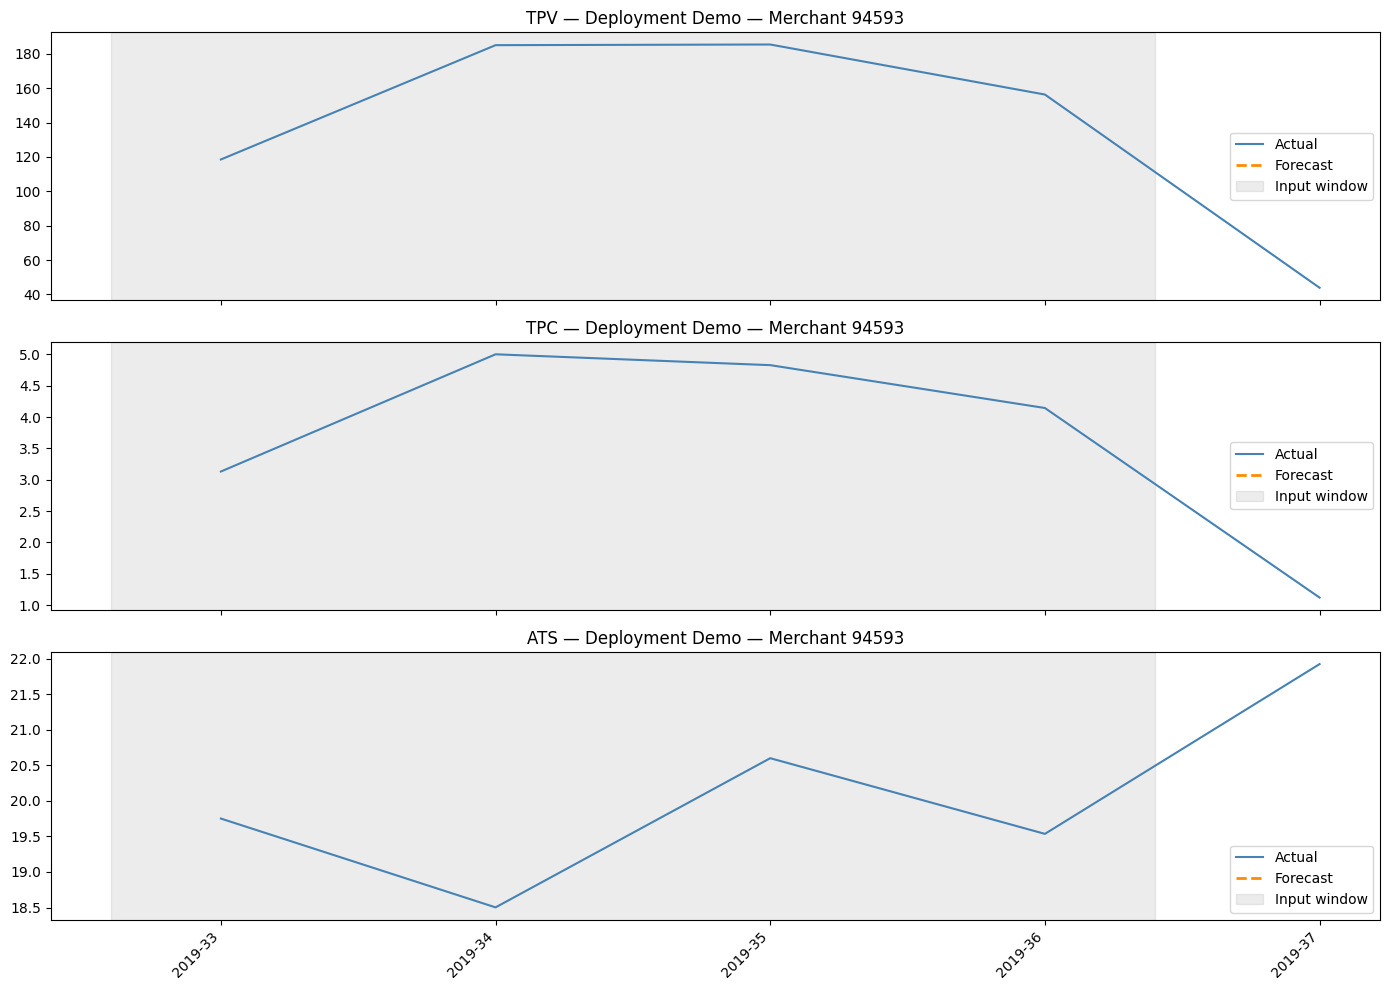

Saved: forecast_demo_plot.png


In [ ]:
# ── Section 13 — Model Persistence ─────────────────────────────────────────

artifacts = {
    'models':                    models,
    'merchant_features_df':      merchant_features_df,
    'merchant_features_scaled':  merchant_features_scaled,
    'merchant_ids':              merchant_ids,
    'scaler':                    scaler,
    'mcc_le':                    mcc_le,
    'merchant_mcc':              merchant_mcc,
    'DEFAULT_ORDER':             DEFAULT_ORDER,
    'DEFAULT_SEASONAL_ORDER':    DEFAULT_SEASONAL_ORDER,
    'TPC_USE_SARIMAX':           TPC_USE_SARIMAX,
    'DEFAULT_K':                 DEFAULT_K,
    'OUTLIER_THRESHOLD':         OUTLIER_THRESHOLD,
    'INPUT_WEEKS':               INPUT_WEEKS,
    'TARGET_WEEKS':              TARGET_WEEKS,
    'eval_metrics':              eval_metrics if 'eval_metrics' in dir() else pd.DataFrame(),
}

with open('sarima_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

merchant_features_df.to_csv('merchant_features.csv', index=False)
if 'eval_metrics' in dir() and len(eval_metrics):
    eval_metrics.to_csv('validation_metrics.csv', index=False)

print('Artifacts saved:')
for p in ['sarima_artifacts.pkl', 'merchant_features.csv', 'failures.csv',
          'skipped.csv', 'validation_metrics.csv',
          'validation_error_distributions.png', 'margin_percentile_forecast.png']:
    exists = Path(p).exists()
    print(f'  {"✓" if exists else "✗"} {p}')


## Deliverables

| File | Description |
|------|-------------|
| `sarima_artifacts.pkl` | Trained SARIMA models + k-NN metadata |
| `merchant_features.csv` | 15-feature merchant vectors |
| `failures.csv` | Merchant/metric fitting failures |
| `skipped.csv` | Merchants skipped (insufficient weeks) |
| `validation_metrics.csv` | Per-merchant MAE/MAPE/RMSE/KL-div on validation set |
| `validation_error_distributions.png` | MAPE & KL-div histograms across merchants |
| `forecast_merchant_*.png` | Sample forecast vs actual plots |
| `margin_percentile_forecast.png` | TPC margin P5/P95 across merchants |

**Data source**: `thiru1711/Financial_Transactions` (HuggingFace) — filtered to MCC 4121  
**Evaluation design**: Input = last 4 weeks of 2017 · Target = first 12 weeks of 2018  
**Merchant split**: 80% train (train on full 2017 history) · 20% validate (only weeks in evaluation windows)